In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

# ── Style des graphiques ──
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_style("whitegrid")
palette = sns.color_palette("viridis", 2)

# ── Chargement des fichiers ──
# Sur Google Colab, uploader les fichiers puis adapter les chemins :
# from google.colab import files
# uploaded = files.upload()

train = pd.read_csv("farms_train.csv")
test  = pd.read_csv("farms_test.csv")

print(f"Train : {train.shape[0]} lignes x {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]} lignes x {test.shape[1]} colonnes")
train.head()

Train : 400 lignes x 8 colonnes
Test  : 120 lignes x 7 colonnes


,DIFF,TOF,AGE,R7,R8,R17,R22,R32
0,1,1,50,0.613,0.19960,0.0425,0.8637,0.2882
1,0,3,40,0.856,0.87970,0.0599,0.6241,0.0917
2,0,3,61,0.396,0.08729,0.0748,0.3028,0.3447
3,0,3,49,0.665,0.39470,0.1100,0.7716,0.2397
4,0,3,47,0.565,0.10440,0.0754,0.3295,0.2094


In [4]:
print("=" * 60)
print("INFORMATIONS GENERALES")
print("=" * 60)
print(train.info())
print("\n")

print("=" * 60)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 60)
print(train.describe().round(3))
print("\n")

print("=" * 60)
print("VALEURS MANQUANTES")
print("=" * 60)
print(train.isnull().sum())
print("\n")

print("=" * 60)
print("DISTRIBUTION DE LA VARIABLE CIBLE (DIFF)")
print("=" * 60)
print(train['DIFF'].value_counts())
print(f"\nProportion saines   (DIFF=1) : {train['DIFF'].mean():.2%}")
print(f"Proportion defaillantes (DIFF=0) : {1 - train['DIFF'].mean():.2%}")



INFORMATIONS GENERALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DIFF    400 non-null    int64  
 1   TOF     400 non-null    int64  
 2   AGE     400 non-null    int64  
 3   R7      400 non-null    float64
 4   R8      400 non-null    float64
 5   R17     400 non-null    float64
 6   R22     400 non-null    float64
 7   R32     400 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 25.1 KB
None


STATISTIQUES DESCRIPTIVES
          DIFF      TOF      AGE       R7       R8      R17      R22      R32
count  400.000  400.000  400.000  400.000  400.000  400.000  400.000  400.000
mean     0.500    2.388   43.732    0.645    0.379    0.066    0.705    0.252
std      0.501    1.177    8.763    0.478    0.343    0.026    1.060    0.122
min      0.000    1.000   24.000    0.051   -0.824    0.020    0.096   -0.142
25%      0.000    1.000   37.

# **VISUS**

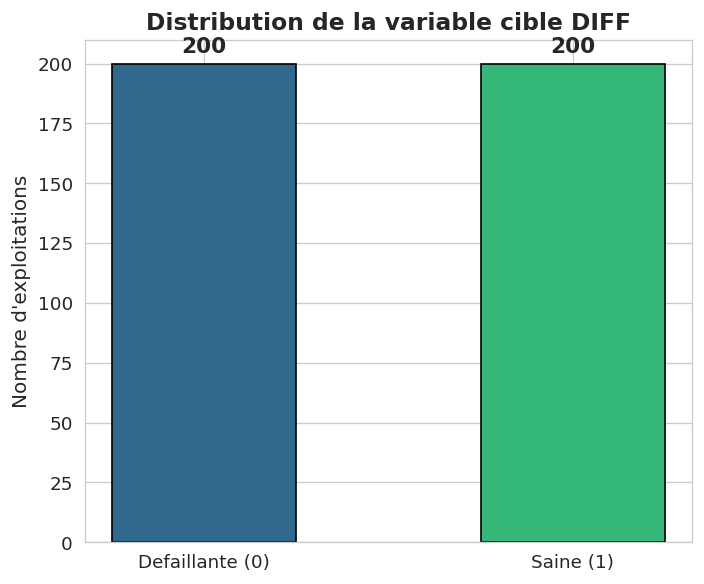

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
counts = train['DIFF'].value_counts().sort_index()
bars = ax.bar(
    ['Defaillante (0)', 'Saine (1)'],
    counts.values,
    color=[palette[0], palette[1]],
    edgecolor='black',
    width=0.5
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_title("Distribution de la variable cible DIFF", fontweight='bold')
ax.set_ylabel("Nombre d'exploitations")
plt.tight_layout()
plt.show()

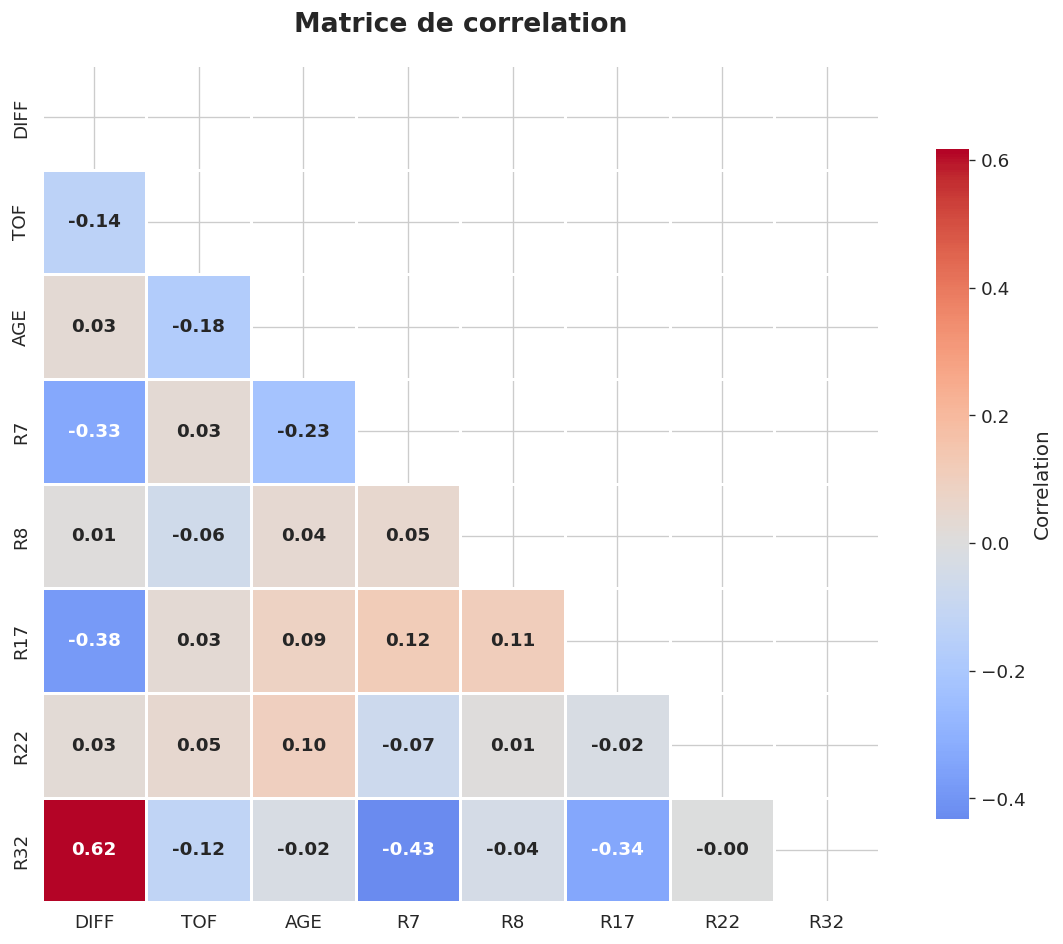


Correlations avec DIFF :
R32    0.618
AGE    0.029
R22    0.025
R8     0.009
TOF   -0.138
R7    -0.334
R17   -0.379
Name: DIFF, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = train.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=1.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    annot_kws={"fontsize": 11, "fontweight": "bold"}
)
ax.set_title("Matrice de correlation", fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelations avec DIFF :")
print(corr['DIFF'].drop('DIFF').sort_values(ascending=False).round(3))

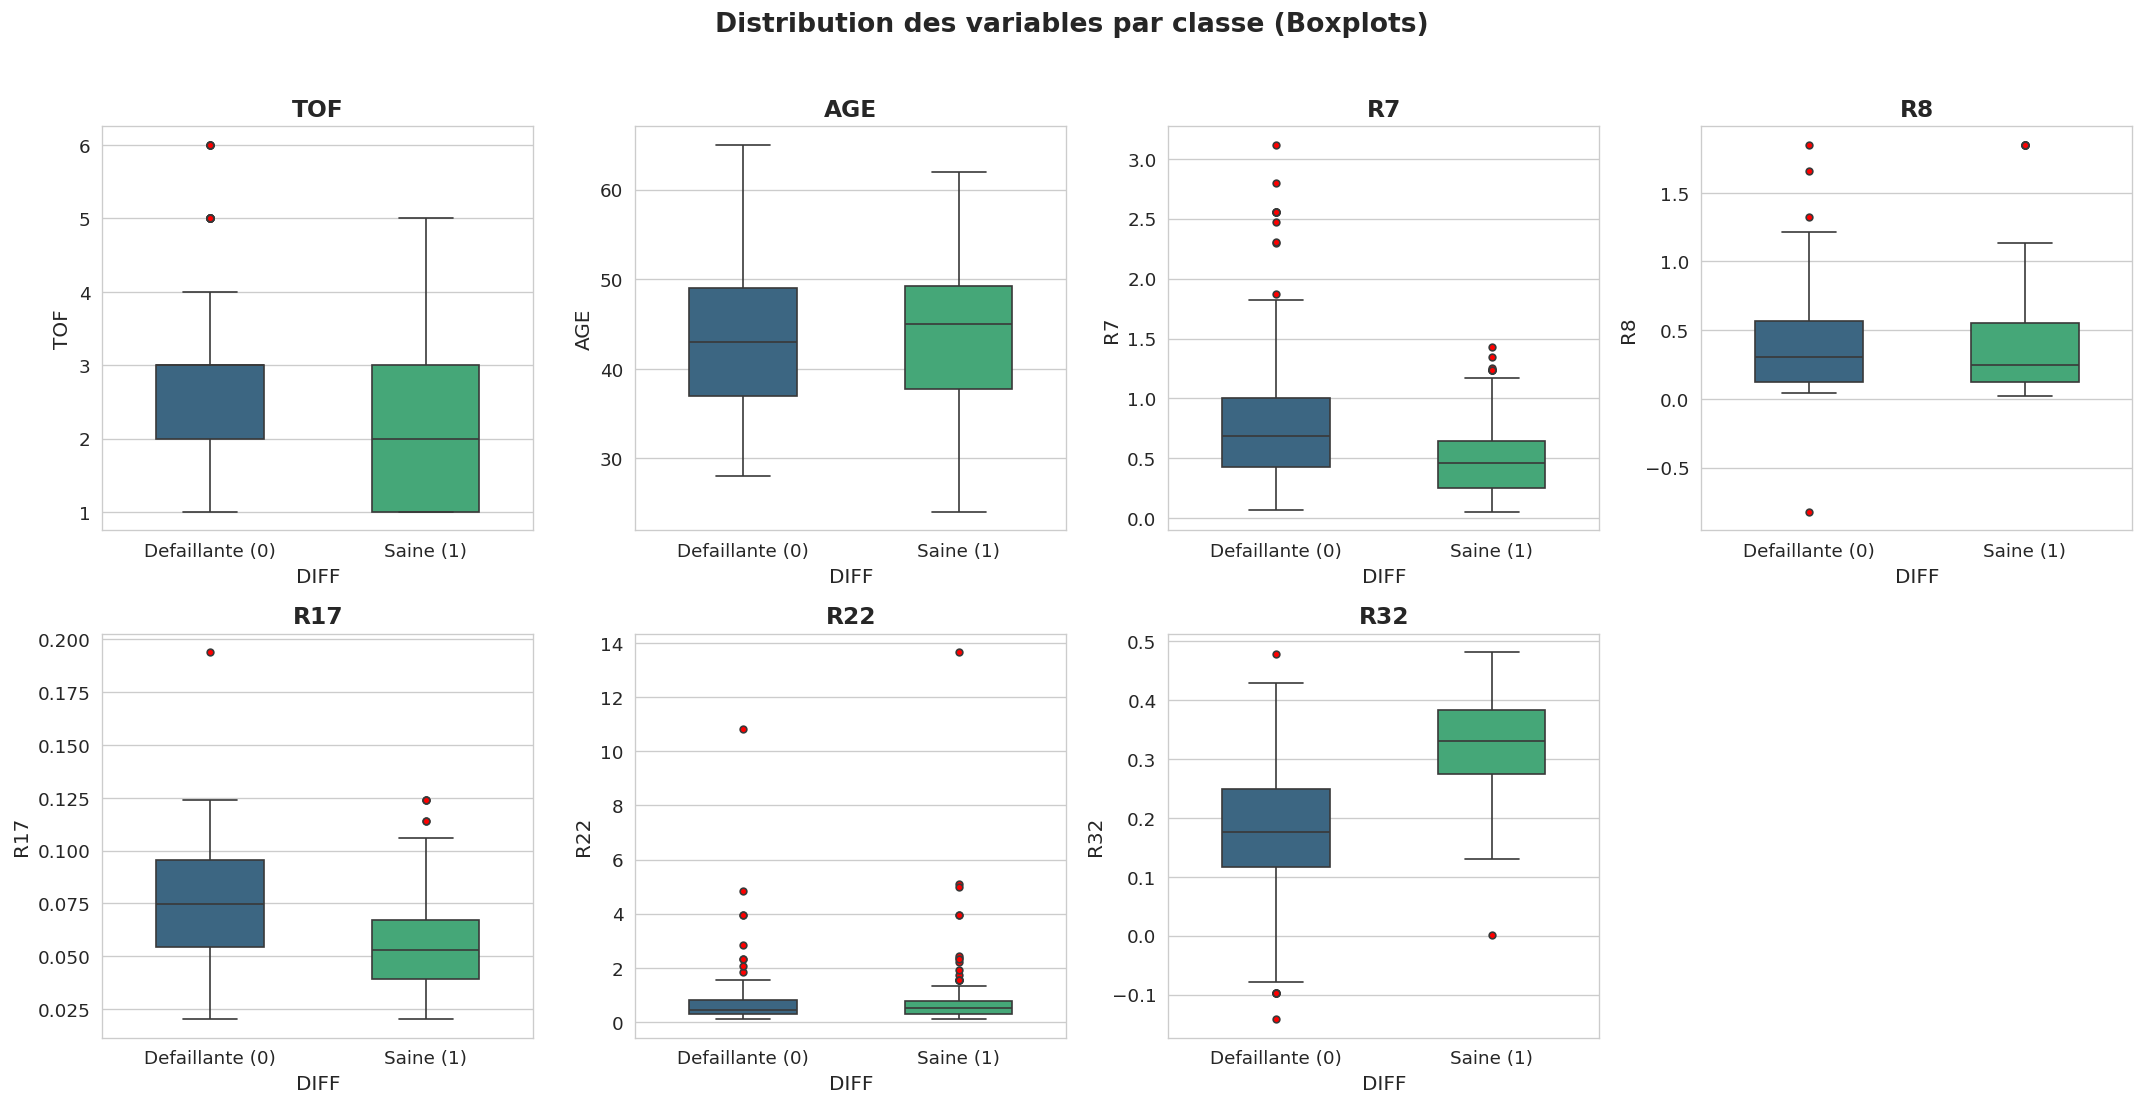

In [7]:
features = ['TOF', 'AGE', 'R7', 'R8', 'R17', 'R22', 'R32']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(
        data=train, x='DIFF', y=feat, ax=axes[i],
        palette=palette, width=0.5,
        flierprops=dict(marker='o', markerfacecolor='red', markersize=4)
    )
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('DIFF')
    axes[i].set_xticklabels(['Defaillante (0)', 'Saine (1)'])

axes[-1].set_visible(False)  # Masquer la 8eme case vide
fig.suptitle("Distribution des variables par classe (Boxplots)", fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

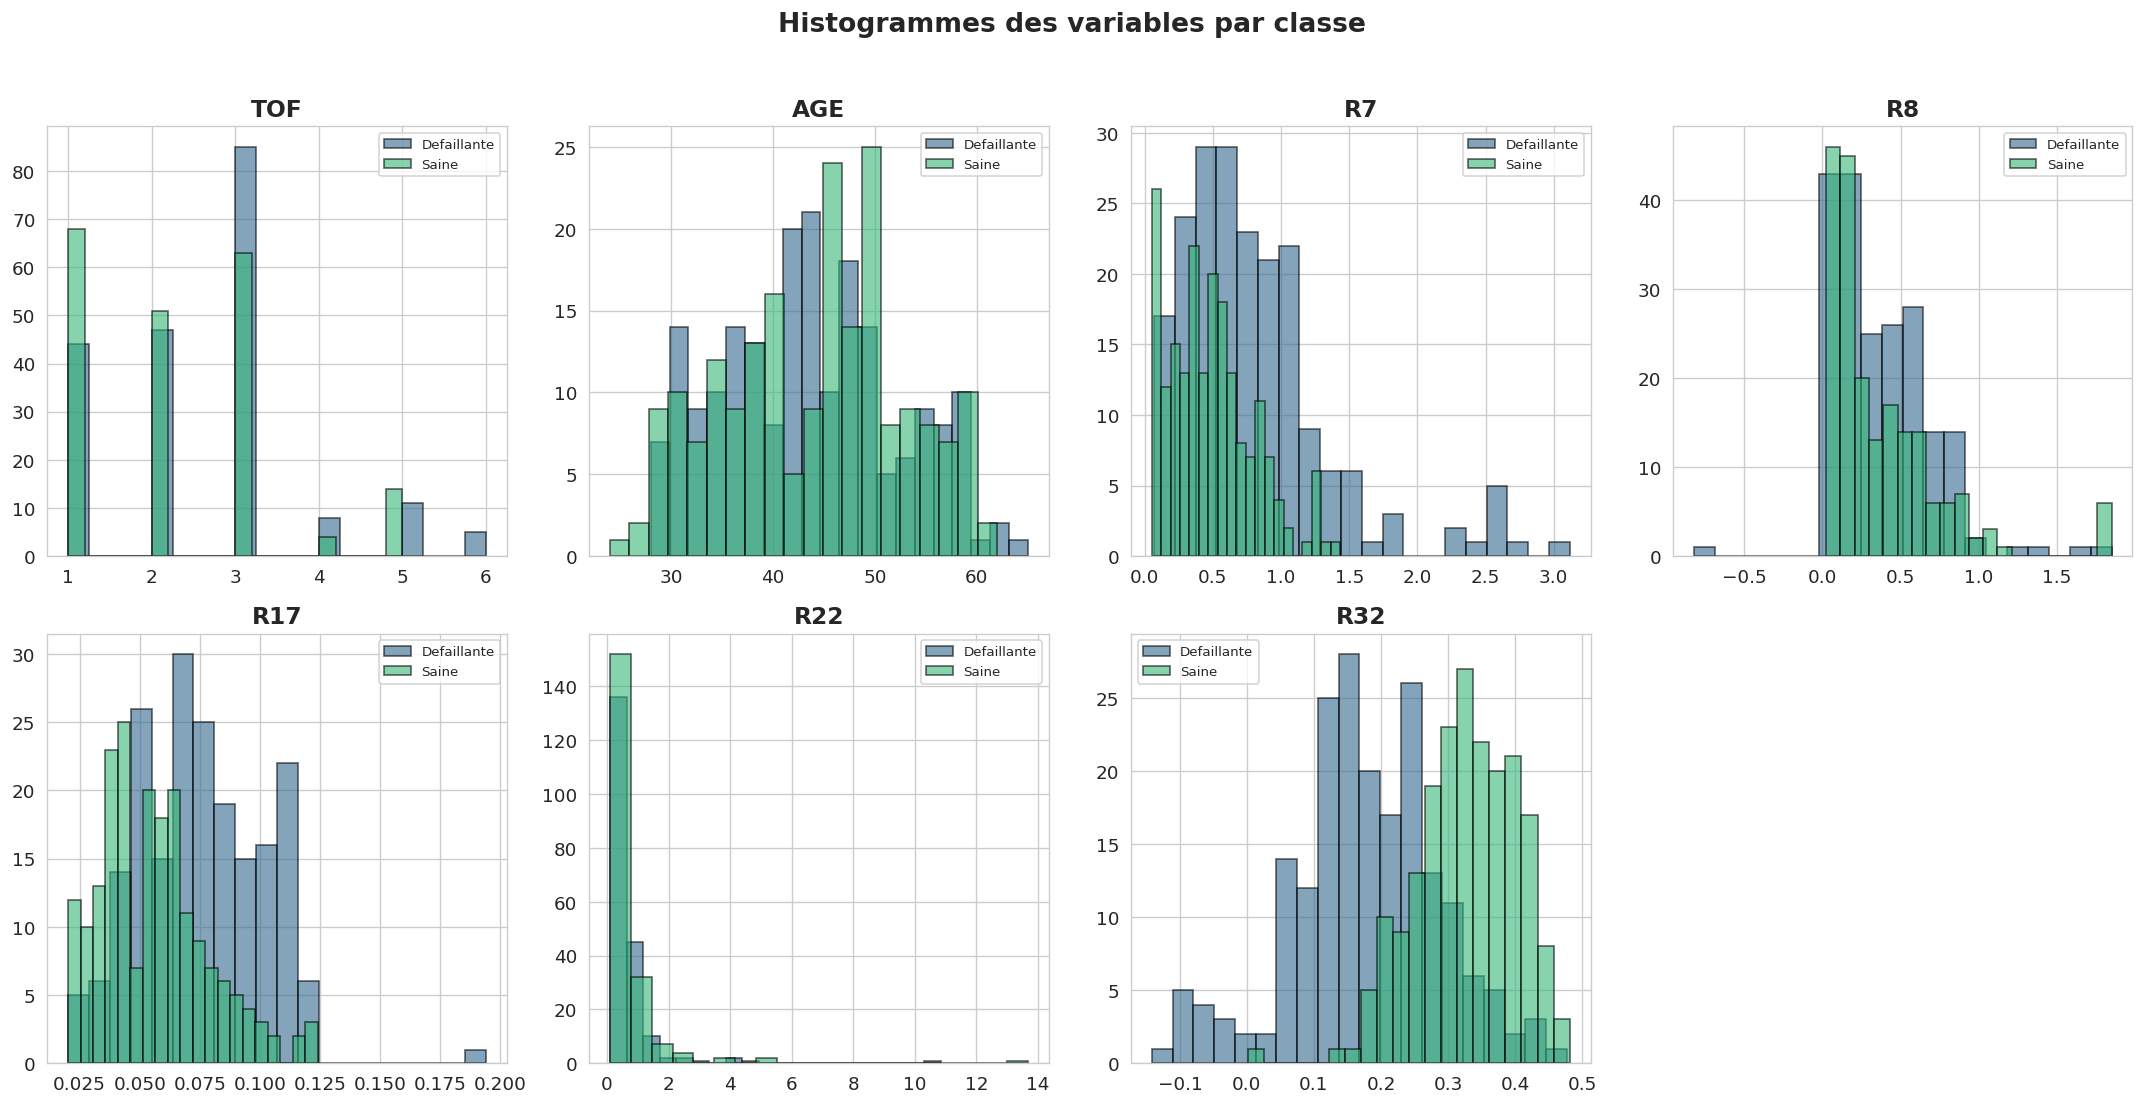

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, color, name in [(0, palette[0], 'Defaillante'), (1, palette[1], 'Saine')]:
        subset = train[train['DIFF'] == label][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=name, edgecolor='black')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle("Histogrammes des variables par classe", fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


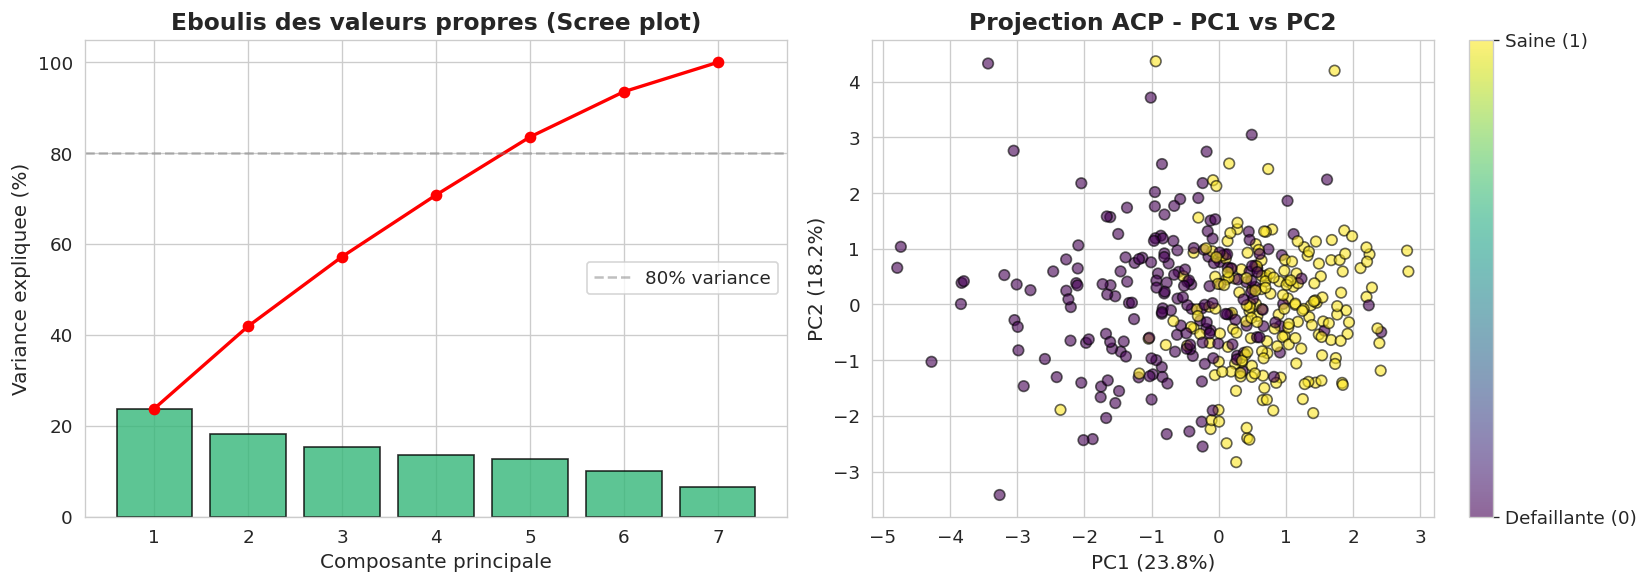


Variance expliquee par composante :
  PC1 : 23.75%  (cumulee : 23.75%)
  PC2 : 18.15%  (cumulee : 41.90%)
  PC3 : 15.31%  (cumulee : 57.21%)
  PC4 : 13.58%  (cumulee : 70.80%)
  PC5 : 12.77%  (cumulee : 83.57%)
  PC6 : 9.97%  (cumulee : 93.54%)
  PC7 : 6.46%  (cumulee : 100.00%)


In [10]:
X_train = train[features].values
y_train = train['DIFF'].values

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# ACP
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled)

# ── Variance expliquee ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eboulis des valeurs propres
axes[0].bar(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_ * 100,
    color=palette[1], edgecolor='black', alpha=0.8
)
axes[0].plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_) * 100,
    'o-', color='red', linewidth=2, markersize=6
)
axes[0].axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% variance')
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("Variance expliquee (%)")
axes[0].set_title("Eboulis des valeurs propres (Scree plot)", fontweight='bold')
axes[0].legend(loc='center right')

# Projection sur PC1 vs PC2
scatter = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_train, cmap='viridis', alpha=0.6, edgecolors='black', s=40
)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Projection ACP - PC1 vs PC2", fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[1], ticks=[0, 1])
cbar.set_ticklabels(['Defaillante (0)', 'Saine (1)'])

plt.tight_layout()
plt.show()

# Affichage de la variance cumulee
print("\nVariance expliquee par composante :")
for i, var in enumerate(pca.explained_variance_ratio_):
    cum = np.sum(pca.explained_variance_ratio_[:i+1])
    print(f"  PC{i+1} : {var*100:.2f}%  (cumulee : {cum*100:.2f}%)")

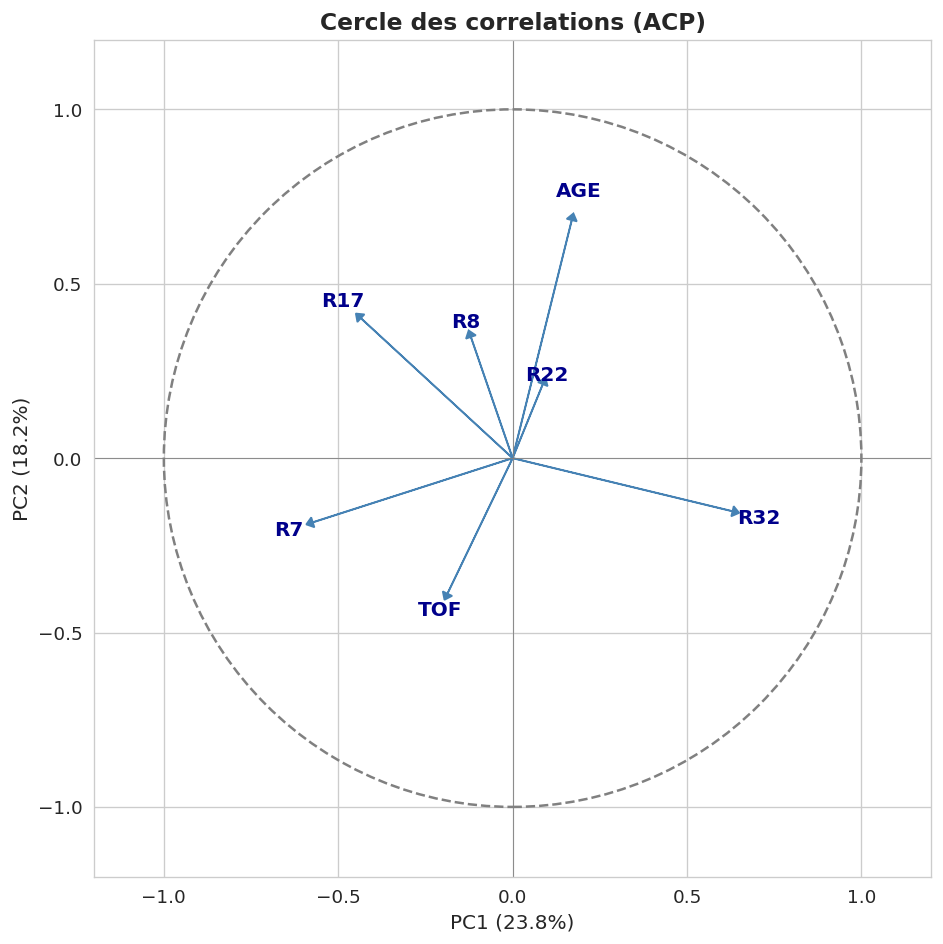

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))

# Cercle unitaire
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linewidth=1.5, linestyle='--')
ax.add_patch(circle)

# Correlations des variables avec PC1 et PC2
loadings = pca.components_[:2].T  # (n_features, 2)
for i, feat in enumerate(features):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
             head_width=0.03, head_length=0.02, fc='steelblue', ec='steelblue')
    ax.text(loadings[i, 0] * 1.12, loadings[i, 1] * 1.12,
            feat, fontsize=12, fontweight='bold', ha='center', va='center',
            color='darkblue')

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
ax.set_title("Cercle des correlations (ACP)", fontweight='bold', fontsize=14)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [12]:
X = train[features].values
y = train['DIFF'].values
X_test = test[features].values

# Standardisation (indispensable pour SVM, KNN, Reg. Logistique)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Validation croisee stratifiee
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"X_train : {X_scaled.shape}")
print(f"X_test  : {X_test_scaled.shape}")
print(f"Classes : {np.unique(y)} -- Repartition : {np.bincount(y)}")

X_train : (400, 7)
X_test  : (120, 7)
Classes : [0 1] -- Repartition : [200 200]


# **Choix du modèle**

In [13]:
print("=" * 60)
print("MODELE 1 : REGRESSION LOGISTIQUE")
print("=" * 60)

# Recherche d'hyperparametres
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1
)
grid_lr.fit(X_scaled, y)

print(f"Meilleurs parametres : {grid_lr.best_params_}")
print(f"Meilleure AUC (CV)   : {grid_lr.best_score_:.4f}")

# Scores en validation croisee
lr_scores = cross_val_score(grid_lr.best_estimator_, X_scaled, y, cv=cv, scoring='roc_auc')
print(f"AUC par fold : {np.round(lr_scores, 4)}")
print(f"AUC moyenne  : {lr_scores.mean():.4f} +/- {lr_scores.std():.4f}")



MODELE 1 : REGRESSION LOGISTIQUE
Meilleurs parametres : {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Meilleure AUC (CV)   : 0.8926
AUC par fold : [0.9156 0.8819 0.8869 0.9625 0.8162]
AUC moyenne  : 0.8926 +/- 0.0477


In [14]:
print("=" * 60)
print("MODELE 2 : SVM (Support Vector Machine)")
print("=" * 60)

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm, cv=cv, scoring='roc_auc', n_jobs=-1
)
grid_svm.fit(X_scaled, y)

print(f"Meilleurs parametres : {grid_svm.best_params_}")
print(f"Meilleure AUC (CV)   : {grid_svm.best_score_:.4f}")

svm_scores = cross_val_score(grid_svm.best_estimator_, X_scaled, y, cv=cv, scoring='roc_auc')
print(f"AUC par fold : {np.round(svm_scores, 4)}")
print(f"AUC moyenne  : {svm_scores.mean():.4f} +/- {svm_scores.std():.4f}")


MODELE 2 : SVM (Support Vector Machine)
Meilleurs parametres : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Meilleure AUC (CV)   : 0.8930
AUC par fold : [0.9119 0.8838 0.8869 0.9612 0.8212]
AUC moyenne  : 0.8930 +/- 0.0454


In [15]:
print("=" * 60)
print("MODELE 3 : ARBRE DE DECISION")
print("=" * 60)

param_grid_dt = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=cv, scoring='roc_auc', n_jobs=-1
)
grid_dt.fit(X_scaled, y)

print(f"Meilleurs parametres : {grid_dt.best_params_}")
print(f"Meilleure AUC (CV)   : {grid_dt.best_score_:.4f}")

dt_scores = cross_val_score(grid_dt.best_estimator_, X_scaled, y, cv=cv, scoring='roc_auc')
print(f"AUC par fold : {np.round(dt_scores, 4)}")
print(f"AUC moyenne  : {dt_scores.mean():.4f} +/- {dt_scores.std():.4f}")



MODELE 3 : ARBRE DE DECISION
Meilleurs parametres : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Meilleure AUC (CV)   : 0.8651
AUC par fold : [0.9394 0.8481 0.8478 0.9081 0.7819]
AUC moyenne  : 0.8651 +/- 0.0546


In [16]:
print("=" * 60)
print("MODELE 4 : KNN (K plus proches voisins)")
print("=" * 60)

param_grid_knn = {
    'n_neighbors': list(range(3, 31, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, cv=cv, scoring='roc_auc', n_jobs=-1
)
grid_knn.fit(X_scaled, y)

print(f"Meilleurs parametres : {grid_knn.best_params_}")
print(f"Meilleure AUC (CV)   : {grid_knn.best_score_:.4f}")

knn_scores = cross_val_score(grid_knn.best_estimator_, X_scaled, y, cv=cv, scoring='roc_auc')
print(f"AUC par fold : {np.round(knn_scores, 4)}")
print(f"AUC moyenne  : {knn_scores.mean():.4f} +/- {knn_scores.std():.4f}")


MODELE 4 : KNN (K plus proches voisins)
Meilleurs parametres : {'metric': 'manhattan', 'n_neighbors': 23, 'weights': 'distance'}
Meilleure AUC (CV)   : 0.8844
AUC par fold : [0.915  0.85   0.8956 0.9312 0.83  ]
AUC moyenne  : 0.8844 +/- 0.0385


## **Résultats**

COMPARAISON DES MODELES
               Modele  AUC Moyenne  AUC Ecart-type
                  SVM     0.893000        0.045355
Regression Logistique     0.892625        0.047735
                  KNN     0.884375        0.038471
    Arbre de Decision     0.865063        0.054555


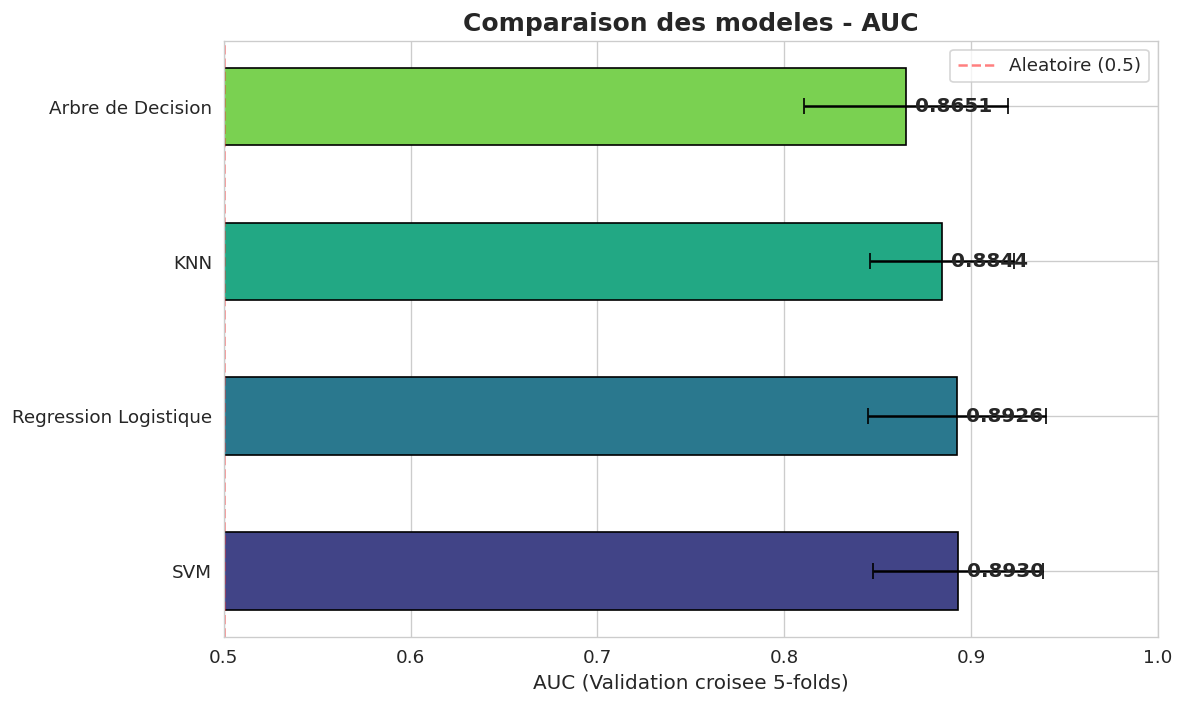

In [17]:
results = pd.DataFrame({
    'Modele': ['Regression Logistique', 'SVM', 'Arbre de Decision', 'KNN'],
    'AUC Moyenne': [lr_scores.mean(), svm_scores.mean(), dt_scores.mean(), knn_scores.mean()],
    'AUC Ecart-type': [lr_scores.std(), svm_scores.std(), dt_scores.std(), knn_scores.std()],
    'Meilleurs Params': [
        str(grid_lr.best_params_),
        str(grid_svm.best_params_),
        str(grid_dt.best_params_),
        str(grid_knn.best_params_)
    ]
}).sort_values('AUC Moyenne', ascending=False).reset_index(drop=True)

print("=" * 60)
print("COMPARAISON DES MODELES")
print("=" * 60)
print(results[['Modele', 'AUC Moyenne', 'AUC Ecart-type']].to_string(index=False))

# Barplot
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("viridis", 4)
bars = ax.barh(
    results['Modele'], results['AUC Moyenne'],
    xerr=results['AUC Ecart-type'],
    color=colors, edgecolor='black', height=0.5,
    capsize=5
)
for bar, val in zip(bars, results['AUC Moyenne']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontweight='bold', fontsize=12)

ax.set_xlabel("AUC (Validation croisee 5-folds)")
ax.set_title("Comparaison des modeles - AUC", fontweight='bold', fontsize=15)
ax.set_xlim(0.5, 1.0)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Aleatoire (0.5)')
ax.legend()
plt.tight_layout()
plt.show()



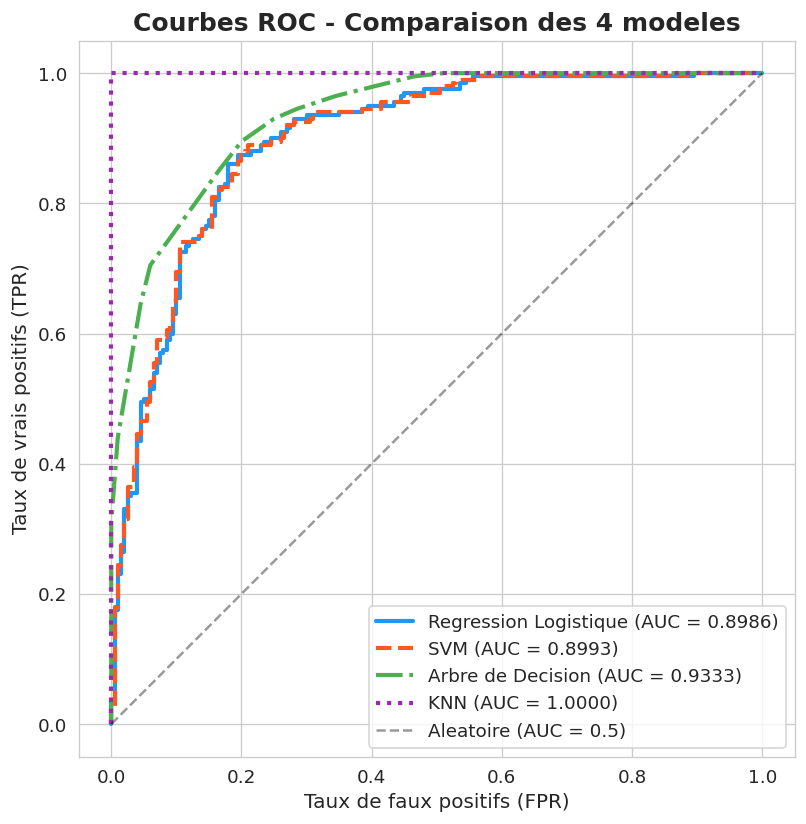

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))

models = {
    'Regression Logistique': grid_lr.best_estimator_,
    'SVM': grid_svm.best_estimator_,
    'Arbre de Decision': grid_dt.best_estimator_,
    'KNN': grid_knn.best_estimator_
}

line_styles = ['-', '--', '-.', ':']
colors_roc = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for (name, model), ls, col in zip(models.items(), line_styles, colors_roc):
    # Prediction probabiliste sur tout le train (pour le graphique)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_scaled)

    fpr, tpr, _ = roc_curve(y, y_prob)
    auc_val = roc_auc_score(y, y_prob)
    ax.plot(fpr, tpr, linestyle=ls, color=col, linewidth=2.5,
            label=f"{name} (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatoire (AUC = 0.5)')
ax.set_xlabel("Taux de faux positifs (FPR)")
ax.set_ylabel("Taux de vrais positifs (TPR)")
ax.set_title("Courbes ROC - Comparaison des 4 modeles", fontweight='bold', fontsize=15)
ax.legend(loc='lower right', fontsize=11)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


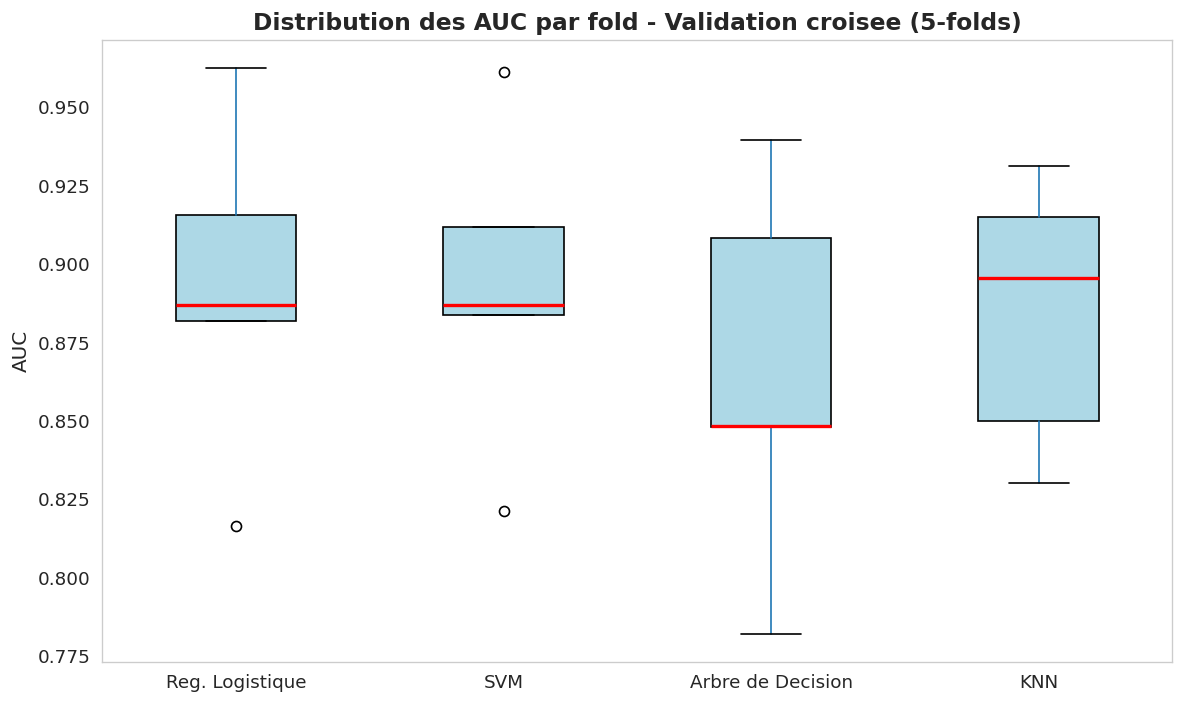

In [19]:
scores_df = pd.DataFrame({
    'Reg. Logistique': lr_scores,
    'SVM': svm_scores,
    'Arbre de Decision': dt_scores,
    'KNN': knn_scores
})

fig, ax = plt.subplots(figsize=(10, 6))
bp = scores_df.boxplot(ax=ax, grid=False, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', edgecolor='black'),
                        medianprops=dict(color='red', linewidth=2))
ax.set_ylabel("AUC")
ax.set_title("Distribution des AUC par fold - Validation croisee (5-folds)", fontweight='bold')
plt.tight_layout()
plt.show()


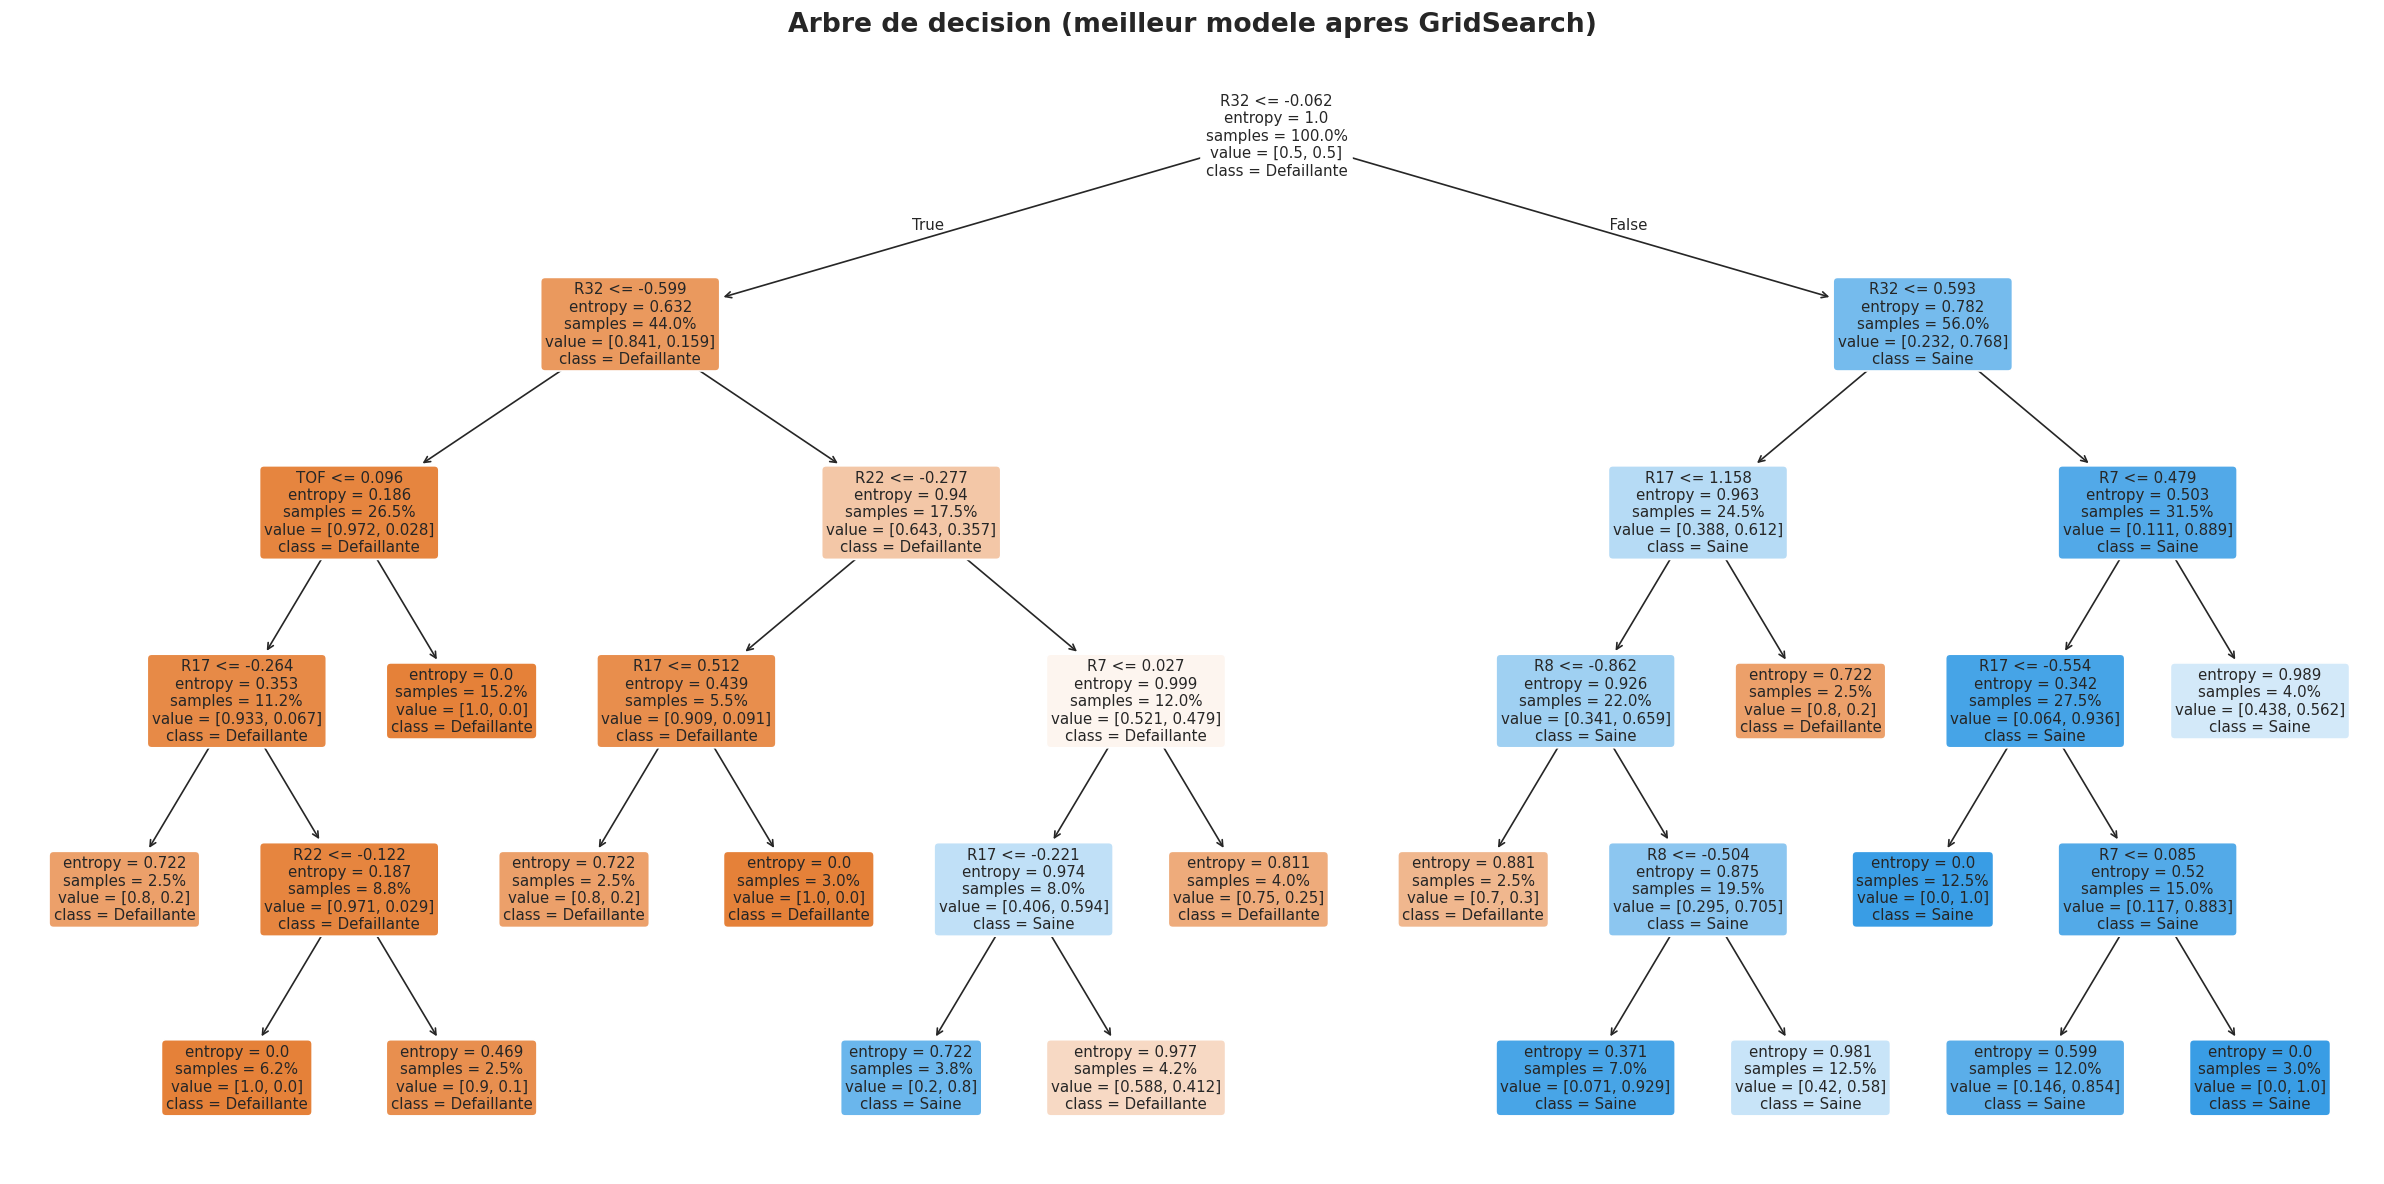

In [20]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    grid_dt.best_estimator_,
    feature_names=features,
    class_names=['Defaillante', 'Saine'],
    filled=True, rounded=True, fontsize=9, ax=ax,
    proportion=True
)
ax.set_title("Arbre de decision (meilleur modele apres GridSearch)", fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

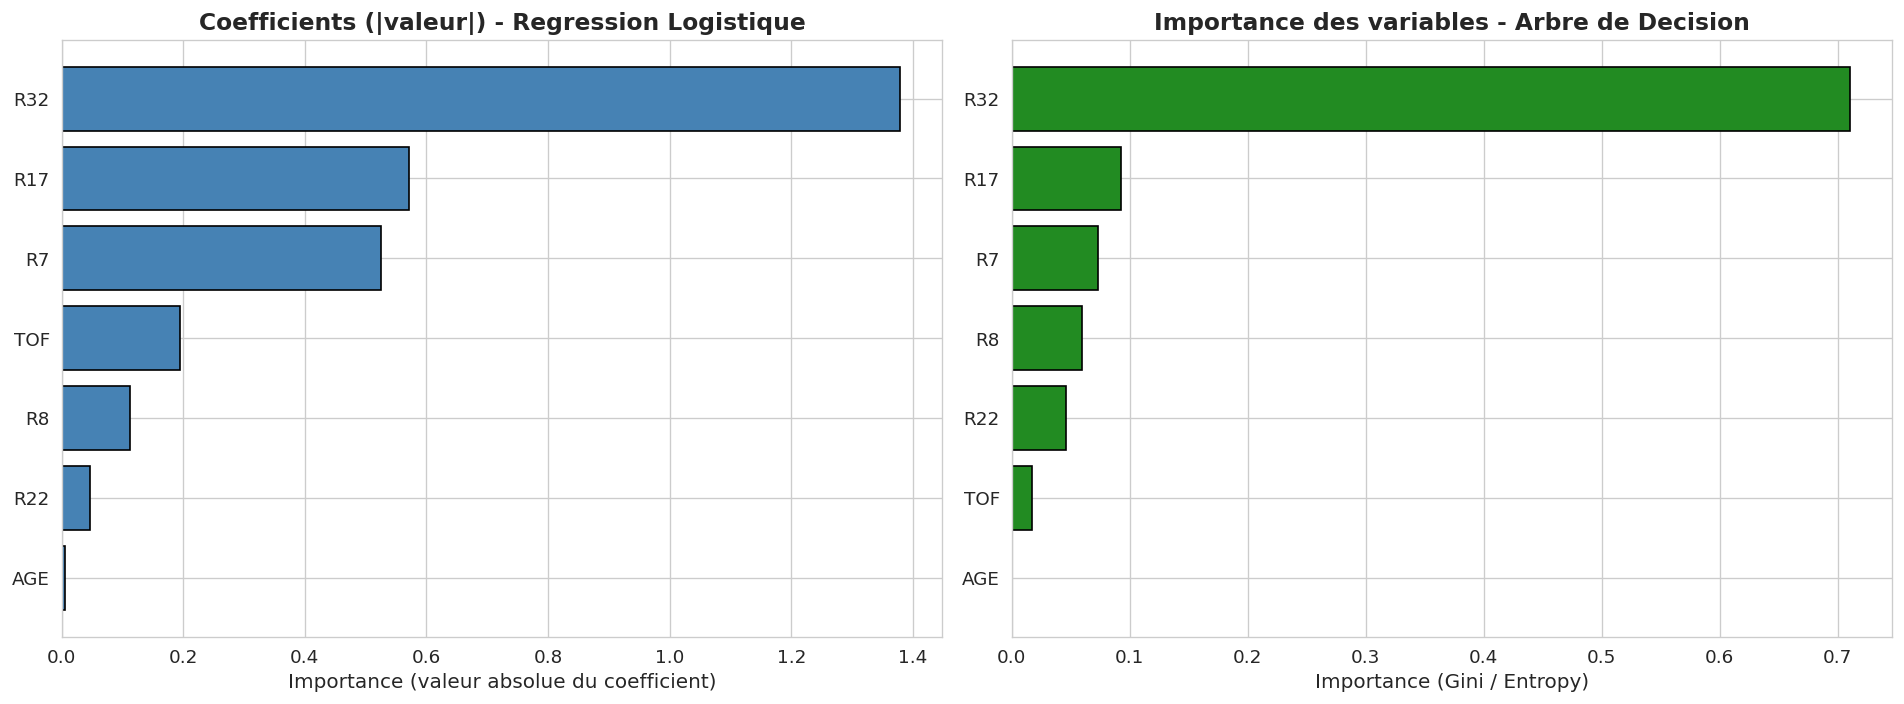

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coefficients de la regression logistique
lr_coefs = pd.Series(
    np.abs(grid_lr.best_estimator_.coef_[0]),
    index=features
).sort_values(ascending=True)

axes[0].barh(lr_coefs.index, lr_coefs.values, color='steelblue', edgecolor='black')
axes[0].set_title("Coefficients (|valeur|) - Regression Logistique", fontweight='bold')
axes[0].set_xlabel("Importance (valeur absolue du coefficient)")

# Importance dans l'arbre de decision
dt_imp = pd.Series(
    grid_dt.best_estimator_.feature_importances_,
    index=features
).sort_values(ascending=True)

axes[1].barh(dt_imp.index, dt_imp.values, color='forestgreen', edgecolor='black')
axes[1].set_title("Importance des variables - Arbre de Decision", fontweight='bold')
axes[1].set_xlabel("Importance (Gini / Entropy)")

plt.tight_layout()
plt.show()

In [22]:
# Identifier le meilleur modele
best_model_name = results.iloc[0]['Modele']
auc_scores = {
    'Regression Logistique': lr_scores.mean(),
    'SVM': svm_scores.mean(),
    'Arbre de Decision': dt_scores.mean(),
    'KNN': knn_scores.mean()
}
best_model = models[best_model_name]

print("=" * 60)
print(f"MEILLEUR MODELE : {best_model_name}")
print(f"AUC Moyenne (CV) : {auc_scores[best_model_name]:.4f}")
print("=" * 60)

# Predictions sur le jeu test
y_pred_test = best_model.predict(X_test_scaled)

# Fichier de soumission
submission = pd.DataFrame({
    'ID': range(1, len(y_pred_test) + 1),
    'DIFF': y_pred_test
})
submission.to_csv("soumission.csv", index=False)

print(f"\nFichier 'soumission.csv' cree avec {len(submission)} predictions.")
print(f"\nApercu :")
print(submission.head(10))
print(f"\nDistribution des predictions :")
print(submission['DIFF'].value_counts().sort_index())

MEILLEUR MODELE : SVM
AUC Moyenne (CV) : 0.8930

Fichier 'soumission.csv' cree avec 120 predictions.

Apercu :
   ID  DIFF
0   1     0
1   2     1
2   3     1
3   4     1
4   5     1
5   6     1
6   7     0
7   8     0
8   9     1
9  10     0

Distribution des predictions :
DIFF
0    51
1    69
Name: count, dtype: int64


In [23]:
print("\n" + "=" * 60)
print("RESUME FINAL")
print("=" * 60)
print(f"\n{'Modele':<25} {'AUC Moyenne':>12} {'Ecart-type':>12}")
print("-" * 50)
for _, row in results.iterrows():
    marker = " *" if row['Modele'] == best_model_name else ""
    print(f"{row['Modele']:<25} {row['AUC Moyenne']:>12.4f} {row['AUC Ecart-type']:>12.4f}{marker}")
print("-" * 50)
print(f"\nModele selectionne : {best_model_name}")
print(f"   AUC = {auc_scores[best_model_name]:.4f}")
print(f"   Fichier de soumission : soumission.csv")
print("=" * 60)


RESUME FINAL

Modele                     AUC Moyenne   Ecart-type
--------------------------------------------------
SVM                             0.8930       0.0454 *
Regression Logistique           0.8926       0.0477
KNN                             0.8844       0.0385
Arbre de Decision               0.8651       0.0546
--------------------------------------------------

Modele selectionne : SVM
   AUC = 0.8930
   Fichier de soumission : soumission.csv
